In [ ]:
#Import dependencies
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from pmdarima.arima import ndiffs, nsdiffs
from pmdarima.model_selection import cross_val_score, RollingForecastCV
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_ccf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from joblib import Parallel, delayed




In [ ]:
#Fetch data
LAT, LON = 56.1629, 10.2039  # Aarhus
START, END = "2025-04-18", "2026-04-18"

# ── 1. Historical air quality (NO2, O3) ──────────────────────────────────────
print("Fetching air quality...")
aq = requests.get(
    "https://air-quality-api.open-meteo.com/v1/air-quality",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "nitrogen_dioxide,ozone,pm10,pm2_5",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

aq_df = pd.DataFrame({
    "Recorded": pd.to_datetime(aq["hourly"]["time"]),
    "NO2":      aq["hourly"]["nitrogen_dioxide"],
    "O3":       aq["hourly"]["ozone"],
    "PM10":     aq["hourly"]["pm10"],
    "PM2.5":    aq["hourly"]["pm2_5"],
})

# ── 2. Historical weather (wind, rain, temp, radiation) ──────────────────────
print("Fetching weather...")
wx = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "wind_speed_10m,temperature_2m,shortwave_radiation,precipitation,relative_humidity_2m",
        "wind_speed_unit": "ms",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

wx_df = pd.DataFrame({
    "Recorded":           pd.to_datetime(wx["hourly"]["time"]),
    "wind_speed":         wx["hourly"]["wind_speed_10m"],
    "temperature":        wx["hourly"]["temperature_2m"],
    "solar_radiation":    wx["hourly"]["shortwave_radiation"],
    "precipitation":      wx["hourly"]["precipitation"],
    "humidity":           wx["hourly"]["relative_humidity_2m"],

})

# ── 3. Merge and save ─────────────────────────────────────────────────────────
print("Merging...")
df = aq_df.merge(wx_df, on="Recorded", how="inner")
df = df.sort_values("Recorded").reset_index(drop=True)

print(f"\nFinal shape: {df.shape}")
print(df.head())
print(f"\nDate range: {df.Recorded.min()} → {df.Recorded.max()}")
print(f"Missing values:\n{df.isnull().sum()}")

#df.to_csv("aarhus_air_quality.csv", index=False)
#print("\nSaved to aarhus_air_quality.csv")

Fetching air quality...
Fetching weather...
Merging...

Final shape: (8784, 10)
             Recorded  NO2    O3  PM10  PM2.5  wind_speed  temperature  \
0 2025-04-18 00:00:00  3.4  90.0   3.8    2.9        4.52          8.3   
1 2025-04-18 01:00:00  3.1  91.0   3.2    2.6        4.51          7.9   
2 2025-04-18 02:00:00  2.5  95.0   3.0    2.1        4.40          7.8   
3 2025-04-18 03:00:00  2.7  92.0   3.1    2.0        4.44          7.8   
4 2025-04-18 04:00:00  2.6  87.0   3.4    2.6        4.70          7.8   

   solar_radiation  precipitation  humidity  
0              0.0            0.0        86  
1              0.0            0.0        87  
2              0.0            0.0        86  
3              0.0            0.0        91  
4              0.0            0.0        89  

Date range: 2025-04-18 00:00:00 → 2026-04-18 23:00:00
Missing values:
Recorded           0
NO2                0
O3                 0
PM10               0
PM2.5              0
wind_speed         0
te

In [ ]:
df.head()

,Recorded,NO2,O3,PM10,PM2.5,wind_speed,wind_direction,temperature,solar_radiation,precipitation,humidity
0,2025-04-18 00:00:00,3.4,90.0,3.8,2.9,4.52,327,8.3,0.0,0.0,86
1,2025-04-18 01:00:00,3.1,91.0,3.2,2.6,4.51,320,7.9,0.0,0.0,87
2,2025-04-18 02:00:00,2.5,95.0,3.0,2.1,4.40,326,7.8,0.0,0.0,86
3,2025-04-18 03:00:00,2.7,92.0,3.1,2.0,4.44,329,7.8,0.0,0.0,91
4,2025-04-18 04:00:00,2.6,87.0,3.4,2.6,4.70,327,7.8,0.0,0.0,89


In [ ]:
# Setup
df["Recorded"] = pd.to_datetime(df["Recorded"])
df = df.set_index('Recorded')


target_col = 'NO2'
m = 24  # seasonal period (hourly data)

y = df[target_col].values
X = df[["temperature"]].values
#X = df.drop(columns=[target_col, "NO2", "O3", "PM10"]).values

# train/test split — hold out last 4 days (96 hours)
holdout = 96
y_train, y_test = y[:-holdout], y[-holdout:]
X_train, X_test = X[:-holdout], X[-holdout:]

In [ ]:
#Scale exogenous features:

# Create scaler
X_scaler = StandardScaler()

#IF only one predictor:
if X_train.ndim == 1:
    X_train = X_train.reshape(-1, 1)
    X_test = X_test.reshape(-1, 1)

# Fit on data 
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

In [58]:
# Determine d and D
d = ndiffs(y_train, test='kpss')
D = nsdiffs(y_train, m=m, test='ch')
print(f"d={d}, D={D}")

d=1, D=1


In [ ]:
candidates = [
    (p, q, P) 
    for p in range(0, 4)
    for q in range(1, 4)  # q minimum 1
    for P in range(0, 2)
]

for p, q, P in candidates:
    try:
        m = SARIMAX(
            y_train,
            exog=X_train_scaled,
            order=(p, d, q),
            seasonal_order=(P, D, 1, 24)  # Q fixed at 1
        ).fit(disp=False)
        print(f"SARIMA({p},{d},{q})({P},{D},1)[24] — AIC: {m.aic:.2f}")
    except:
        print(f"SARIMA({p},{d},{q})({P},{D},1)[24] — failed")

SARIMA(0,1,1)(0,1,1)[24] — AIC: 22395.52
SARIMA(0,1,1)(1,1,1)[24] — AIC: 22384.27
SARIMA(0,1,2)(0,1,1)[24] — AIC: 22303.77
SARIMA(0,1,2)(1,1,1)[24] — AIC: 22292.21
SARIMA(0,1,3)(0,1,1)[24] — AIC: 22305.39
SARIMA(0,1,3)(1,1,1)[24] — AIC: 22293.75
SARIMA(1,1,1)(0,1,1)[24] — AIC: 22315.04
SARIMA(1,1,1)(1,1,1)[24] — AIC: 22303.36
SARIMA(1,1,2)(0,1,1)[24] — AIC: 22305.61


/work/IdaMunchAndresen#2017/air-quality-forecasting/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(1,1,2)(1,1,1)[24] — AIC: 22294.01


/work/IdaMunchAndresen#2017/air-quality-forecasting/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(1,1,3)(0,1,1)[24] — AIC: 22045.22


...

SARIMA(3,1,2)(1,1,1)[24] — AIC: 22034.10


/work/IdaMunchAndresen#2017/air-quality-forecasting/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(3,1,3)(0,1,1)[24] — AIC: 22036.52


/work/IdaMunchAndresen#2017/air-quality-forecasting/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(3,1,3)(1,1,1)[24] — AIC: 22017.43


In [37]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# refit with statsmodels
statsmodels_model = SARIMAX(
    y_train,
    exog=X_train_scaled,
    order=(3,1,1),
    seasonal_order=(1,1,1,24)
).fit(disp=False)

# now residuals work cleanly
residuals = statsmodels_model.resid

print(statsmodels_model.summary())

/work/IdaMunchAndresen#2017/air-quality-forecasting/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 8688
Model:             SARIMAX(3, 1, 1)x(1, 1, 1, 24)   Log Likelihood              -10998.343
Date:                            Wed, 20 May 2026   AIC                          22014.686
Time:                                    11:22:17   BIC                          22078.287
Sample:                                         0   HQIC                         22036.369
                                           - 8688                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.8894      0.134     -6.634      0.000      -1.152      -0.627
x2            -0.1342      0.033   

/work/IdaMunchAndresen#2017/air-quality-forecasting/.venv/lib/python3.12/site-packages/pmdarima/utils/visualization.py:220: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  res = tsaplots.plot_acf(


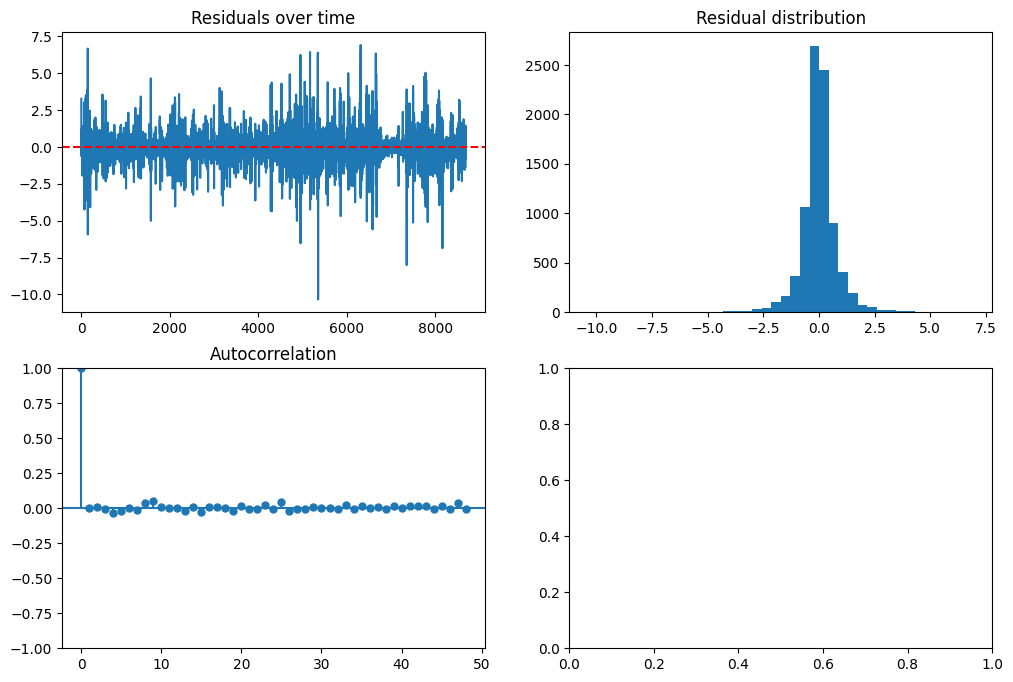

<Figure size 640x480 with 0 Axes>

      lb_stat     lb_pvalue
24  75.522603  3.092750e-07


In [38]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# residuals over time
axes[0, 0].plot(residuals)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals over time')

# histogram
axes[0, 1].hist(residuals, bins=40)
axes[0, 1].set_title('Residual distribution')

# ACF of residuals
pm.utils.plot_acf(residuals, ax=axes[1, 0], lags=48)
axes[1, 0].set_title('ACF of residuals')

# PACF of residuals
pm.utils.plot_pacf(residuals, ax=axes[1, 1], lags=48)
axes[1, 1].set_title('PACF of residuals')

plt.tight_layout()
plt.show()

# Ljung-Box test — p-value should be > 0.05 (no autocorrelation left)
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[24], return_df=True)
print(lb_test)


In [ ]:
# Cross-validation
cv = RollingForecastCV(h=24, step=12)

scores = cross_val_score(
    model, y_train,
    X=X_train,
    cv=cv,
    scoring='mean_absolute_error'
)
print(f"CV MAE scores: {scores}")
print(f"Mean CV MAE:   {np.mean(scores):.4f}")

In [ ]:
# Final evaluation on hold-out
# refit on full training data
model.fit(y_train, X=X_train)
forecast = model.predict(n_periods=holdout, X=X_test)

mae = np.mean(np.abs(forecast - y_test))
print(f"Hold-out MAE: {mae:.4f}")

# plot forecast vs actuals
plt.figure(figsize=(12, 4))
plt.plot(y_test, label='Actual')
plt.plot(forecast, label='Forecast', linestyle='--')
plt.legend()
plt.title('Hold-out forecast vs actuals')
plt.show()